In [1]:
%pip install -r ../../requirements-offline.txt --quiet

/Users/utarn/projects/ml-metrology/.claude/worktrees/issue-27/.venv/bin/python: No module named pip


Note: you may need to restart the kernel to use updated packages.


# Module M2 — Thai OCR: ข้อมูลทดสอบ → CER

**Day 1, 13:00–14:30 · Offline (CPU)**

เมื่อจบโมดูลนี้ ผู้เรียนจะ:
1. รู้ว่างาน OCR วัดผลกันอย่างไร — **CER (Character Error Rate)** คำนวณด้วย `jiwer`
2. ทำ **bake-off** เทียบ 3 โมเดล OCR ภาษาไทยจริงบนชุดทดสอบเดียวกัน:
   **Tesseract (`tha`)** · **EasyOCR** · **thai-trocr**
3. ใช้ **Surya** ทำ layout analysis + table extraction บนสแกนหน้ารายงานการวัด
4. เข้าใจว่าผล OCR ต่างกันนำไปใช้ต่างกันอย่างไร (โดยเฉพาะงานดิจิทัลไลซ์เอกสารเมโทรโลยี)

**Dataset ที่ใช้:** `openthaigpt/thai-ocr-evaluation` (test split, 104 ภาพ) — Sapsathien, S. &
Jaroenkantasima, J., openthaigpt, <https://huggingface.co/datasets/openthaigpt/thai-ocr-evaluation>,
**License: CC BY-SA 4.0** (เก็บไว้ใน repo แล้วที่ `datasets/thai_ocr_evaluation/`)

**โมเดล/เครื่องมือที่ใช้ (license):**
- Tesseract 5 + `tha` traineddata (Apache-2.0) — **โปรแกรมระดับระบบ** ติดตั้งก่อนวันอบรม
  (README §ก่อนวันอบรม); ไฟล์ `tha/eng.traineddata` สำรองไว้ใน repo ที่ `datasets/tessdata/`
- EasyOCR 1.7 (Apache-2.0) — โมเดลดาวน์โหลดครั้งแรกไปที่ cache ของ EasyOCR
- `openthaigpt/thai-trocr` (Apache-2.0) — โหลดผ่าน `transformers` (HF cache)
- Surya 0.17 (โค้ด Apache-2.0; weights ของ Datalab — ตรวจ model card ก่อนแจกต่อ)
- `jiwer` 4.0 (Apache-2.0) สำหรับคำนวณ CER

> **ข้อตกลงการรัน:** เปิด JupyterLab จาก repo root (`uv run jupyter lab`) — kernel
> รันในโฟลเดอร์ของ notebook เอง โค้ดจึงหา repo root ด้วยการไล่ parent


เซลล์แรกคือ `%pip install -r` จากไฟล์ pin ของ repo — ถ้าติดตั้งผ่าน `uv sync` แล้วจะขึ้น
`No module named pip` ซึ่ง**ไม่ใช่ปัญหา** (แพ็กเกจครบแล้วจาก uv.lock) ข้ามผลเซลล์นี้ได้

## 1. ชุดข้อมูลทดสอบ — thai-ocr-evaluation

ชุดทดสอบนี้แบ่งเป็น 5 หมวด: `handwritten` (ลายมือ), `document` (พิมพ์จากเอกสารราชการ),
`document_enth` (เอกสารผสมอังกฤษ), `real_document` (เอกสารจริง), `scene_text`
(ตัวหนังสือบนฉาก เช่น ป้าย/โปสเตอร์) — ทุกภาพเป็น "บรรทัด" ระดับ 1–3 บรรทัด

เราสุ่มภาพ **หมวดละ 4 ภาพ = 20 ภาพ** แบบ fix seed เพื่อให้ทุกเครื่องได้ชุดเดียวกัน
และ bake-off จบใน ~1 นาทีบน CPU


In [2]:
import csv  # noqa: E402
from pathlib import Path  # noqa: E402


def repo_root() -> Path:
    """หา repo root โดยไล่ขึ้นจาก cwd."""
    for p in (Path.cwd(), *Path.cwd().parents):
        if (p / "requirements-offline.txt").exists():
            return p
    raise SystemExit(
        "ไม่พบ repo root — เปิด JupyterLab จาก repo root (uv run jupyter lab)"
    )


ROOT = repo_root()
DATA = ROOT / "datasets" / "thai_ocr_evaluation" / "test"
REPORTS = ROOT / "datasets" / "measurement_reports"
TESSDATA = ROOT / "datasets" / "tessdata"
assert (DATA / "metadata.csv").exists(), (
    "ไม่พบ thai_ocr_evaluation — ดู datasets/README.md"
)
assert TESSDATA.exists(), "ไม่พบ datasets/tessdata — เช็คว่า repo ครบ"
print("repo root:", ROOT)


repo root: /Users/utarn/projects/ml-metrology/.claude/worktrees/issue-27


In [3]:
import numpy as np  # noqa: E402
import pandas as pd  # noqa: E402

meta = list(csv.DictReader(open(DATA / "metadata.csv", encoding="utf-8")))
truth = {r["file_name"]: r["text"] for r in meta}

cats: dict[str, list[str]] = {}
for r in meta:
    cats.setdefault(r["category"], []).append(r["file_name"])

rng = np.random.default_rng(42)
subset: list[tuple[str, str]] = []
for cat in sorted(cats):
    files = sorted(cats[cat])
    idx = sorted(rng.choice(len(files), 4, replace=False))
    subset += [(cat, files[i]) for i in idx]

print("จำนวนภาพในชุด bake-off:", len(subset))
print(pd.Series([c for c, _ in subset]).value_counts())


จำนวนภาพในชุด bake-off: 20
document         4
document_enth    4
handwritten      4
real_document    4
scene_text       4
Name: count, dtype: int64


/tmp/ipykernel_6322/1939184855.py:10: UserWarning: Glyph 3592 (\N{THAI CHARACTER CHO CHAN}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_6322/1939184855.py:10: UserWarning: Glyph 3591 (\N{THAI CHARACTER NGO NGU}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_6322/1939184855.py:10: UserWarning: Glyph 3648 (\N{THAI CHARACTER SARA E}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_6322/1939184855.py:10: UserWarning: Glyph 3619 (\N{THAI CHARACTER RO RUA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_6322/1939184855.py:10: UserWarning: Glyph 3618 (\N{THAI CHARACTER YO YAK}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_6322/1939184855.py:10: UserWarning: Glyph 3609 (\N{THAI CHARACTER NO NU}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_6322/1939184855.py:10: UserWarning: Glyph 3617 (\N{THAI CHARACTER MO MA}) missing from font(s) DejaVu Sans.
  plt

/Users/utarn/projects/ml-metrology/.claude/worktrees/issue-27/.venv/lib/python3.14/site-packages/IPython/core/pylabtools.py:158: UserWarning: Glyph 3627 (\N{THAI CHARACTER HO HIP}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/utarn/projects/ml-metrology/.claude/worktrees/issue-27/.venv/lib/python3.14/site-packages/IPython/core/pylabtools.py:158: UserWarning: Glyph 3624 (\N{THAI CHARACTER SO SALA}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/utarn/projects/ml-metrology/.claude/worktrees/issue-27/.venv/lib/python3.14/site-packages/IPython/core/pylabtools.py:158: UserWarning: Glyph 3608 (\N{THAI CHARACTER THO THONG}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


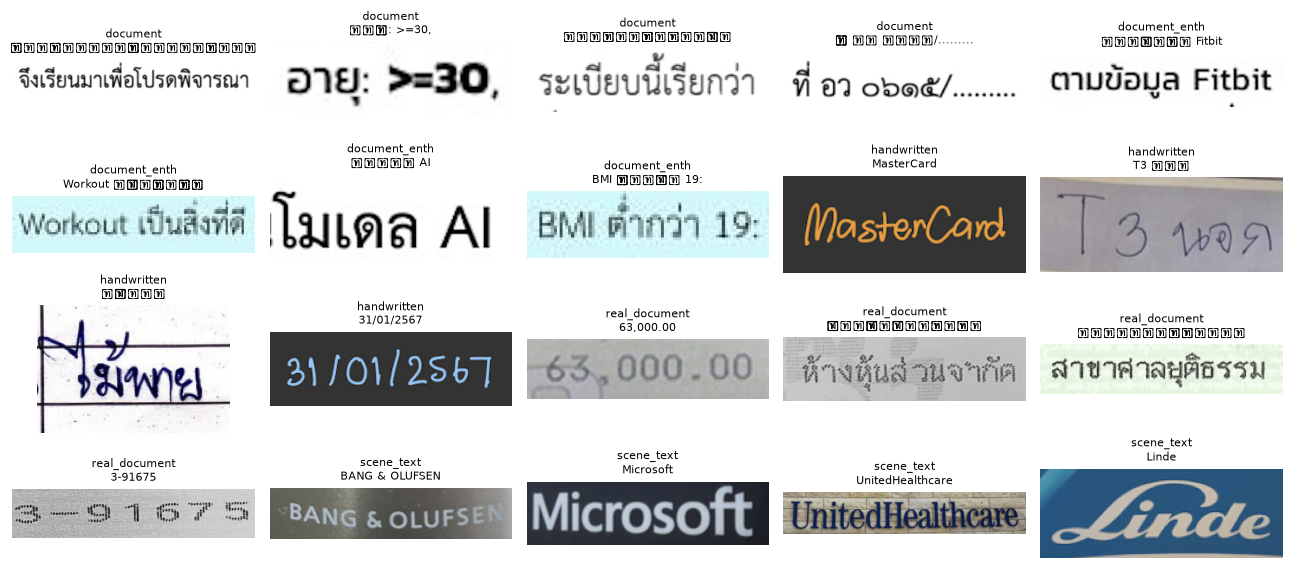

In [4]:
import matplotlib.pyplot as plt  # noqa: E402
from PIL import Image  # noqa: E402

fig, axes = plt.subplots(4, 5, figsize=(13, 6))
for ax, (cat, fn) in zip(axes.ravel(), subset):
    img = Image.open(DATA / fn).convert("RGB")
    ax.imshow(img)
    ax.set_title(f"{cat}\n{truth[fn][:24]}", fontsize=8)
    ax.axis("off")
plt.tight_layout()
plt.show()


## 2. CER — ไม้บรรทัดวัด OCR

**CER (Character Error Rate)** = จำนวนการแก้ไขขั้นต่ำ (แทน/ลบ/เพิ่มตัวอักษร)
**หาร** ด้วยความยาวข้อความจริง (Levenshtein distance ระดับตัวอักษร)

- CER = 0 → อ่านถูกทุกตัวอักษร
- CER = 0.1 → เฉลี่ยผิด 1 ตัวทุก ๆ 10 ตัวอักษร
- ภาษาไทยยากกว่าภาษาละติน: สระบน-ล่าง วรรณยุกต์ซ้อน และคำไม่มีช่องว่างคั่น

เราใช้ `jiwer.cer(reference, hypothesis)` — รับได้ทั้ง string เดียวและ list
(สำหรับ list จะรวม error ทุกภาพแล้วหารด้วยความยาวรวมของ reference ทั้งหมด)


In [5]:
import jiwer  # noqa: E402, F401

ref = "อุณหภูมิ 24.6 °C"
for hyp, note in [
    ("อุณหภูมิ 24.6 °C", "อ่านถูกหมด"),
    ("อุณหภูมิ 24.5 °C", "ผิดตัวเลข 1 ตัว"),
    ("อุนหภูมิ 24.6 C", "หล่น สระอู + °"),
]:
    print(f"CER={jiwer.cer(ref, hyp):.3f}  ({note})")


CER=0.000  (อ่านถูกหมด)
CER=0.062  (ผิดตัวเลข 1 ตัว)
CER=0.125  (หล่น สระอู + °)


## 3. Bake-off โมเดลที่ 1 — Tesseract (`tha`)

Tesseract เป็น **โปรแกรมระดับระบบ** (ไม่ได้อยู่ใน pip) — ตรวจว่าติดตั้งแล้ว:
`brew install tesseract` (macOS) หรือ `sudo apt install tesseract-ocr` (Ubuntu)

ไฟล์ภาษา `tha.traineddata` (tessdata_best, Apache-2.0) เราเก็บใน repo ที่
`datasets/tessdata/` แล้ว — สั่ง tesseract ให้ใช้ผ่าน `--tessdata-dir`
(ไม่ต้องพึ่งพาตำแหน่ง tessdata ของระบบเลย)

> ข้อสังเกต: เราส่ง **พาธไฟล์** เข้า `pytesseract.image_to_string` ตรง ๆ
> ไม่ใช่ PIL image — tesseract 5.5 + leptonica ใหม่มีปัญหาอ่านภาพจาก stdin


In [6]:
import pytesseract  # noqa: E402

assert TESSDATA.exists(), "ไม่พบ datasets/tessdata — เช็คว่า repo ครบ"


def ocr_tesseract(path, lang="tha") -> str:
    """OCR ไฟล์ภาพหนึ่งไฟล์ด้วย tesseract + traineddata ใน repo."""
    cfg = f"--tessdata-dir {TESSDATA}"
    txt = pytesseract.image_to_string(str(path), lang=lang, config=cfg)
    return " ".join(txt.split())


tess_out = {}
for cat, fn in subset:
    tess_out[fn] = ocr_tesseract(DATA / fn)

for cat, fn in subset[:4]:
    print(f"[{cat}] GT  : {truth[fn]}")
    print(f"        tess: {tess_out[fn]}")


[document] GT  : จึงเรียนมาเพื่อโปรดพิจารณา
        tess: ซูซ ซ่ = จึงเรียนมาเพื่อโปรดพิจารณา
[document] GT  : อายุ: >=30,
        tess: อาย: >=30,
[document] GT  : ระเบียบนี้เรียกว่า
        tess: ซื่องเลื้สื่อ๓๓. ระเบยบนเรยกวา
[document] GT  : ที่ อว ๐๖๑๕/.........
        tess: ที อว ๐๐๑๕222


In [7]:
refs = [truth[fn].strip() for _, fn in subset]
hyps = [tess_out[fn] for _, fn in subset]
tess_cer = jiwer.cer(refs, hyps)
print("Tesseract tha — CER รวม =", round(tess_cer, 3))


Tesseract tha — CER รวม = 0.723


CER ราว 0.7 แปลว่า "ผิดเกือบ 7 ใน 10 ตัวอักษร" — Tesseract `tha` แทบใช้ไม่ได้กับ
ภาพกลุ่มนี้ (ตัวเลขของ model card ของ thai-trocr ก็รายงานเช่นเดียวกัน ~1.0)
สาเหตุหลัก: engine ตรวจหาบรรทัด/ตัดคำภาษาไทยของ tesseract อ่อน และ
`traineddata` สำหรับไทยอิงข้อมูลเก่า

## 4. โมเดลที่ 2 — EasyOCR

EasyOCR = detection (หากล่องข้อความ) + recognition (อ่านตัวอักษร) ในตัวเดียว
ภาษาไทยใช้โมเดล recognition `thai_g2` (จับคู่กับ `en` ได้) — โมเดลจะถูกดาวน์โหลด
**ครั้งแรกครั้งเดียว** (~90 MB) ไปที่ cache ของ EasyOCR (`~/.EasyOCR`);
เครื่องอบรมที่ pre-bundle แล้วจะโหลดจากดิสก์ทันที


In [8]:
import easyocr  # noqa: E402
from PIL import Image  # noqa: E402

reader = easyocr.Reader(["th", "en"], gpu=False, verbose=False)

easy_out = {}
for cat, fn in subset:
    img = Image.open(DATA / fn).convert("RGB")
    lines = reader.readtext(np.array(img), detail=0)
    easy_out[fn] = " ".join(lines)

for cat, fn in subset[:4]:
    print(f"[{cat}] GT   : {truth[fn]}")
    print(f"         easy: {easy_out[fn]}")


/Users/utarn/projects/ml-metrology/.claude/worktrees/issue-27/.venv/lib/python3.14/site-packages/torch/ao/nn/quantized/dynamic/modules/rnn.py:162: UserWarning: torch.quantize_per_tensor, torch.quantize_per_channel and other quantized tensor creation functions that produce tensors with dtype torch.quint8, torch.qint8, and torch.qint32 are deprecated and will be removed in a future PyTorch release. Please see https://github.com/pytorch/pytorch/issues/184982 for more information. (Triggered internally at /Users/runner/work/pytorch/pytorch/aten/src/ATen/quantized/Quantizer.cpp:116.)
  w_ih = torch.quantize_per_tensor(
/Users/utarn/projects/ml-metrology/.claude/worktrees/issue-27/.venv/lib/python3.14/site-packages/torch/utils/data/dataloader.py:759: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)


[document] GT   : จึงเรียนมาเพื่อโปรดพิจารณา
         easy:  จึงเรียนมาเพื่อโปรดพิจารณา
[document] GT   : อายุ: >=30,
         easy: อาย: >=30
[document] GT   : ระเบียบนี้เรียกว่า
         easy:  ระเบียบนี้เรียกว่า
[document] GT   : ที่ อว ๐๖๑๕/.........
         easy: ที่ อว ๑๖๑๕/.


In [9]:
hyps = [easy_out[fn] for _, fn in subset]
easy_cer = jiwer.cer(refs, hyps)
print(f"EasyOCR — CER รวม 20 ภาพ = {easy_cer:.3f}")


EasyOCR — CER รวม 20 ภาพ = 0.315


## 5. โมเดลที่ 3 — thai-trocr (transformers)

`openthaigpt/thai-trocr` = TrOCR (ViT encoder + decoder ภาษาไทย) เทรนสำหรับ
ข้อความไทย/อังกฤษ — ตัวนี้อ่าน**ภาพบรรทัดเดียว**ได้ดีมาก (ชุดทดสอบของเราก็เป็น
บรรทัดระดับ 1–3 บรรทัด จึงใช้ได้ตรง ๆ)

โมเดล ~0.4 GB (วัดจริงจาก HF — model card เคยประมาณ 1.3 GB) อยู่ที่ **HF cache** (`~/.cache/huggingface`) — เครื่องอบรมที่
pre-bundle แล้วโหลดจากดิสก์ทันที: เราลอง `local_files_only=True` ก่อนเสมอ
ถ้าไม่มีในเครื่องจริง ค่อย fallback ไปดาวน์โหลด (ต้องมีอินเทอร์เน็ตครั้งเดียว)


In [10]:
import torch  # noqa: E402
from transformers import TrOCRProcessor  # noqa: E402
from transformers import VisionEncoderDecoderModel  # noqa: E402

MODEL_ID = "openthaigpt/thai-trocr"
try:
    processor = TrOCRProcessor.from_pretrained(MODEL_ID, local_files_only=True)
    trocr = VisionEncoderDecoderModel.from_pretrained(
        MODEL_ID, local_files_only=True
    )
    print("โหลดจาก HF cache ในเครื่อง (offline) — สำเร็จ")
except OSError:
    print("ยังไม่มีใน cache — ดาวน์โหลดครั้งแรก (ต้องมีอินเทอร์เน็ต)")
    processor = TrOCRProcessor.from_pretrained(MODEL_ID)
    trocr = VisionEncoderDecoderModel.from_pretrained(MODEL_ID)
trocr.eval()


def ocr_trocr(path) -> str:
    """OCR ภาพบรรทัดเดียวด้วย thai-trocr."""
    img = Image.open(path).convert("RGB")
    pv = processor(images=img, return_tensors="pt").pixel_values
    with torch.inference_mode():
        ids = trocr.generate(pv, max_new_tokens=64)
    return processor.batch_decode(ids, skip_special_tokens=True)[0]


/Users/utarn/projects/ml-metrology/.claude/worktrees/issue-27/.venv/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Using a slow image processor as `use_fast` is unset and a slow processor was saved with this model. `use_fast=True` will be the default behavior in v4.52, even if the model was saved with a slow processor. This will result in minor differences in outputs. You'll still be able to use a slow processor with `use_fast=False`.


โหลดจาก HF cache ในเครื่อง (offline) — สำเร็จ


In [11]:
trocr_out = {}
for cat, fn in subset:
    trocr_out[fn] = ocr_trocr(DATA / fn)

for cat, fn in subset[:4]:
    print(f"[{cat}] GT    : {truth[fn]}")
    print(f"          trocr: {trocr_out[fn]}")

hyps = [trocr_out[fn] for _, fn in subset]
trocr_cer = jiwer.cer(refs, hyps)
print(f"thai-trocr — CER รวม 20 ภาพ = {trocr_cer:.3f}")


[document] GT    : จึงเรียนมาเพื่อโปรดพิจารณา
          trocr: จึงเรียนมาเพื่อโปรดพิจารณา
[document] GT    : อายุ: >=30,
          trocr: อายุ: >>30,
[document] GT    : ระเบียบนี้เรียกว่า
          trocr: ระเบียบนี้เรียกว่า
[document] GT    : ที่ อว ๐๖๑๕/.........
          trocr: ที่ อว ๐๖๑๕...____
thai-trocr — CER รวม 20 ภาพ = 0.135


## 6. สรุป bake-off

ประกอบ CER ของ 3 โมเดล แยกตามหมวดภาพ (เอียงไปทางไหนเห็นชัดในกราฟ)


category       document  document_enth  handwritten  real_document  \
model                                                                
EasyOCR           0.153          0.396        0.333          0.727   
Tesseract tha     0.558          0.416        0.850          1.613   
thai-trocr        0.106          0.079        0.258          0.393   

category       scene_text    ALL  
model                             
EasyOCR             0.359  0.394  
Tesseract tha       1.031  0.894  
thai-trocr          0.036  0.174  


/tmp/ipykernel_6322/2356903762.py:23: UserWarning: Glyph 3618 (\N{THAI CHARACTER YO YAK}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_6322/2356903762.py:23: UserWarning: Glyph 3591 (\N{THAI CHARACTER NGO NGU}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_6322/2356903762.py:23: UserWarning: Glyph 3605 (\N{THAI CHARACTER TO TAO}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_6322/2356903762.py:23: UserWarning: Glyph 3604 (\N{THAI CHARACTER DO DEK}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_6322/2356903762.py:23: UserWarning: Glyph 3648 (\N{THAI CHARACTER SARA E}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_6322/2356903762.py:23: UserWarning: Glyph 3593 (\N{THAI CHARACTER CHO CHING}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_6322/2356903762.py:23: UserWarning: Glyph 3621 (\N{THAI CHARACTER LO LING}) missing from font(s) DejaVu Sans.
 

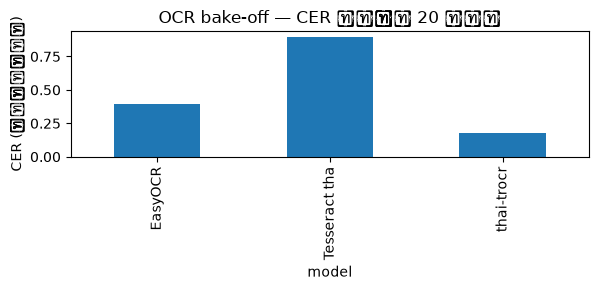

In [12]:
rows = []
for name, out in [
    ("Tesseract tha", tess_out),
    ("EasyOCR", easy_out),
    ("thai-trocr", trocr_out),
]:
    for cat, fn in subset:
        rows.append(
            {
                "model": name,
                "category": cat,
                "cer": jiwer.cer(truth[fn].strip(), out[fn]),
            }
        )
df = pd.DataFrame(rows)
summary = df.pivot_table(index="model", columns="category", values="cer")
summary["ALL"] = df.groupby("model")["cer"].mean()
print(summary.round(3))

ax = summary["ALL"].plot.bar(figsize=(6, 3), legend=False)
ax.set_ylabel("CER (ยิ่งต่ำยิ่งดี)")
ax.set_title("OCR bake-off — CER เฉลี่ย 20 ภาพ")
plt.tight_layout()
plt.show()


**อ่านผล:**
- **Tesseract `tha`** — แย่สุด (CER ~0.7): ใช้เป็น baseline "ตัวเก่า" ได้ แต่ใช้งานจริงกับไทยไม่ได้
- **EasyOCR** — กลาง ๆ: ดีกับพิมพ์ชัด แต่สะกดผิดบ่อย (สระ/วรรณยุกต์) และพังกับ
  เอกสารจริงคุณภาพสแกนแปรปรวน (`real_document` ~0.73 ต่อภาพเฉลี่ย)
- **thai-trocr** — ดีสุดในบรรทัดเดียว: เทรนมาเฉพาะไทย แต่**ใช้กับหน้าเอกสารหลายบรรทัดตรง ๆ ไม่ได้**
  ต้องตัดบรรทัดก่อน (line segmentation — เช่น ด้วย Surya ในขั้นถัดไป)

สำหรับงานเมโทรโลยี (แปลงสแกนรายงานการวัดเป็นข้อมูล): ถามกลับว่า ค่า CER เท่าไร
ถึง "พอใช้"? — ถ้าค่าที่ผิดคือ**ตัวเลขค่าการวัด** ผิด 1 ตัว = ค่าผิดทั้งจุด โจทย์จริงจึงไม่ใช่
"โมเดลไหนชนะ" แต่คือ "pipeline ไหน + การตรวจสอบมนุษย์เท่าไร ถึงเชื่อผลได้"

## 7. Surya — layout analysis + table extraction บนหน้ารายงานการวัด

ภาพสแกนหน้ารายงานการวัดตัวอย่าง (สังเคราะห์ขึ้นเอง — license-clean) อยู่ที่
`datasets/measurement_reports/` Surya ตรวจหา **โครงสร้างหน้ากระดาษ** (หัวเรื่อง,
ย่อหน้า, ตาราง, รูป) และ **โครงสร้างตาราง** (แถว/คอลัมน์/ช่อง) ได้ — สองอย่างที่
OCR ข้อความธรรมดาไม่บอก

โมเดลของ Surya อยู่ที่ cache `MODEL_CACHE_DIR` (ค่าเริ่มต้นตาม OS — เครื่อง
อบรม pre-bundle ไว้แล้ว) — โมเดล layout กับ table-rec เป็นตัวแยกกัน (~450 MB
รวมกัน)

> หมายเหตุเวอร์ชัน: repo ใช้ **surya-ocr 0.16.7** — เวอร์ชันหลังจากนี้ (0.17+)
> เปลี่ยน layout เป็น foundation-model token-decoder ที่บนหน้าเอกสารจริงให้
> กล่องเดียวเสีย ๆ (วัดจริงแล้ว: 1 กล่อง `PageHeader` บนหน้าตาราง+กราฟของเรา)
> และ ≥ 0.20 ย้ายไปใช้ VLM ที่ต้องมี llama-server + ไฟล์ GGUF หลาย GB —
> ขัดเงื่อนไข offline CPU ทั้งคู่ 0.16.7 ยังเป็น torch model แยกชิ้นที่รัน
> เฉพาะเครื่องได้


In [13]:
from surya.layout import LayoutPredictor  # noqa: E402
from surya.table_rec import TableRecPredictor  # noqa: E402

layout_pred = LayoutPredictor()
table_pred = TableRecPredictor()
print("โหลดโมเดล Surya ครบ (layout + table-rec, CPU)")


`TableRecEncoderDecoderModel` is not compatible with mps backend. Defaulting to cpu instead


โหลดโมเดล Surya ครบ (layout + table-rec, CPU)


### 7.1 Layout analysis — หน้ารายงานที่มีตาราง + กราฟ

เราใช้หน้าผลการประเมิน (มีตาราง + กราฟ error curve) แล้ววาดกล่องโครงสร้างทับภาพ


In [14]:
PAGE_TABLES = sorted(REPORTS.glob("*.png"))[3]  # หน้าที่มีตาราง+กราฟ
print("ใช้ภาพ:", PAGE_TABLES.name)
page = Image.open(PAGE_TABLES).convert("RGB")

layouts = layout_pred([page])[0]
labels = [b.label for b in layouts.bboxes]
print(pd.Series(labels).value_counts())


ใช้ภาพ: page04.png


Recognizing layout:   0%|          | 0/1 [00:00<?, ?it/s]

Recognizing layout: 100%|██████████| 1/1 [00:02<00:00,  2.44s/it]

Recognizing layout: 100%|██████████| 1/1 [00:02<00:00,  2.44s/it]

Text             3
PageHeader       2
SectionHeader    2
PageFooter       2
Table            1
Figure           1
Name: count, dtype: int64


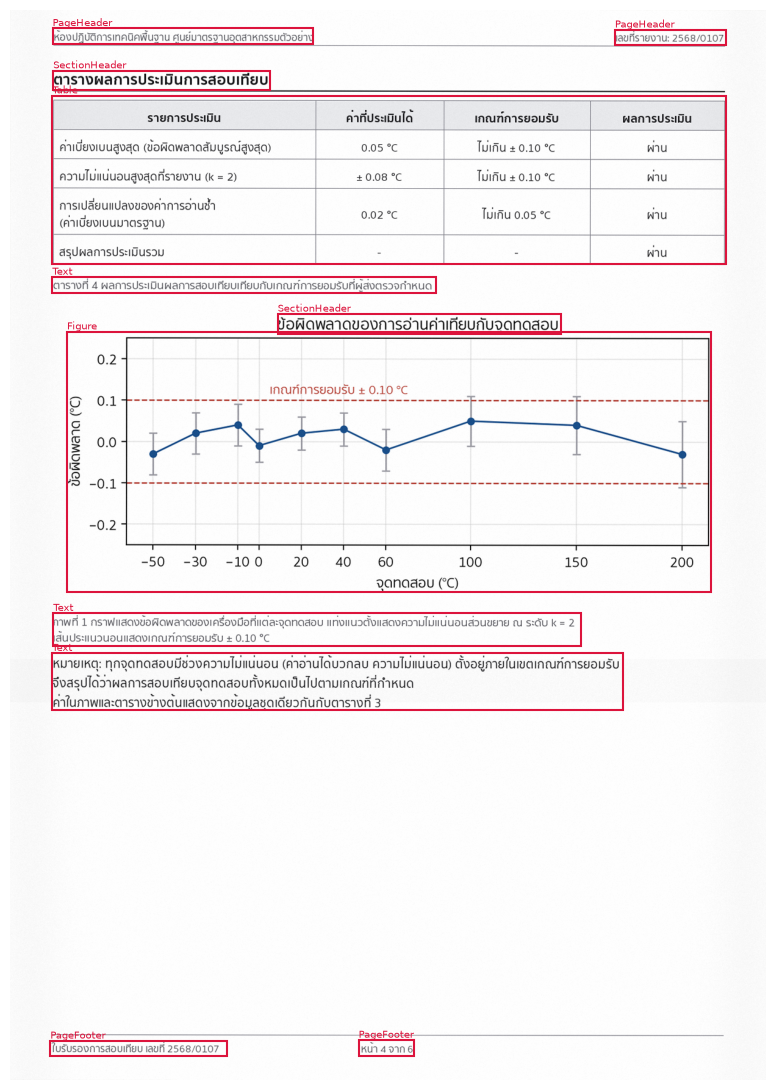

In [15]:
import matplotlib.patches as mpatches  # noqa: E402

fig, ax = plt.subplots(figsize=(8, 11))
ax.imshow(page)
for b in layouts.bboxes:
    x0, y0, x1, y1 = b.bbox
    ax.add_patch(
        mpatches.Rectangle(
            (x0, y0), x1 - x0, y1 - y0, fill=False,
            edgecolor="crimson", linewidth=1.5,
        )
    )
    ax.text(x0, max(y0 - 4, 4), b.label, color="crimson", fontsize=7)
ax.axis("off")
plt.tight_layout()
plt.show()


### 7.2 Table extraction — ตารางผลการสอบเทียบ

Surya แยกตารางเป็น **rows / cols / cells** (เรขาคณิต) — จากนั้นเราเลือกอ่านข้อความ
ในแต่ละช่องด้วย OCR ตัวใดก็ได้ที่เจอมาแล้ว (ที่นี่ใช้ tesseract เพราะเร็ว)


In [16]:
PAGE_TABLE = sorted(REPORTS.glob("*.png"))[2]  # หน้าตารางผลการวัด
img_t = Image.open(PAGE_TABLE).convert("RGB")

tres = table_pred([img_t])[0]
print(f"rows={len(tres.rows)} cols={len(tres.cols)} cells={len(tres.cells)}")


Recognizing tables:   0%|          | 0/1 [00:00<?, ?it/s]

Recognizing tables: 100%|██████████| 1/1 [00:00<00:00,  1.23it/s]

Recognizing tables: 100%|██████████| 1/1 [00:00<00:00,  1.23it/s]

rows=23 cols=5 cells=115


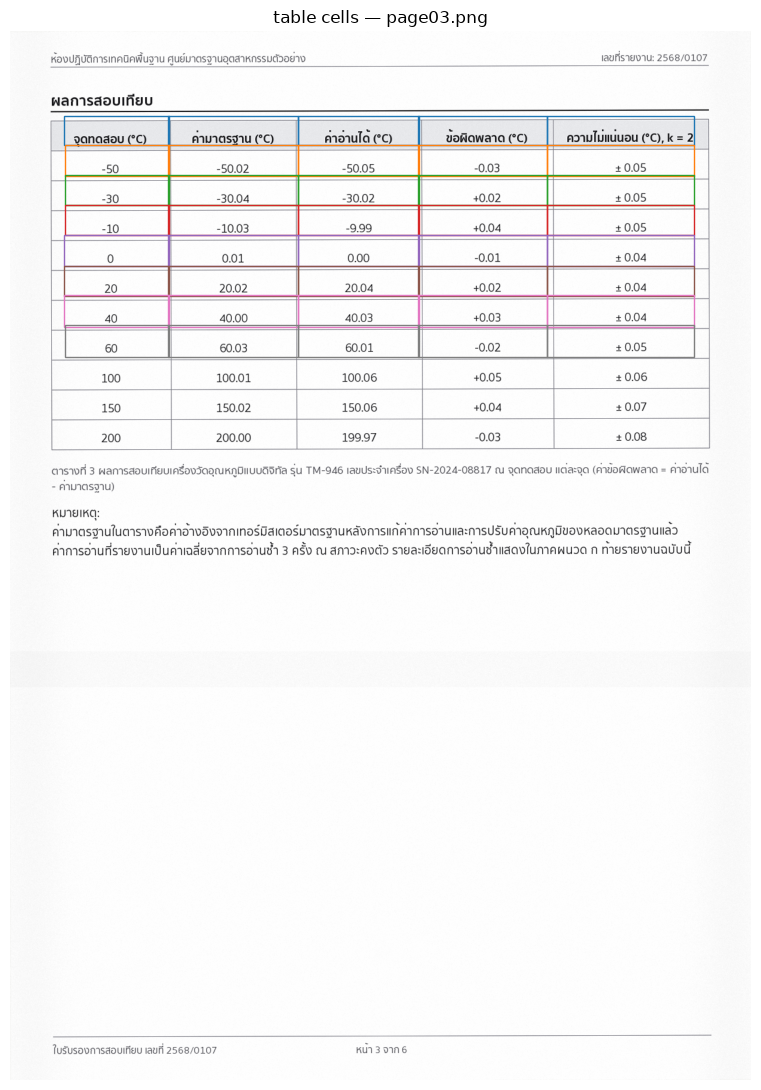

'จดทดสอบ (°C)'
'ค่ามาตรฐาน °C) |'


'ค่าอ่านได้ (*@'
'ข้อผิดพลาด (°C)'


'ความไม่แน่นอน (°C), k = 2'


In [17]:
import matplotlib  # noqa: E402

fig, ax = plt.subplots(figsize=(8, 11))
ax.imshow(img_t)
for cell in tres.cells[:40]:
    x0, y0, x1, y1 = cell.bbox
    ax.add_patch(
        mpatches.Rectangle(
            (x0, y0), x1 - x0, y1 - y0, fill=False,
            edgecolor=matplotlib.colormaps["tab10"](cell.row_id % 10),
            linewidth=1,
        )
    )
ax.set_title(f"table cells — {PAGE_TABLE.name}")
ax.axis("off")
plt.tight_layout()
plt.show()

# อ่านข้อความช่องแรก ๆ ด้วย tesseract เพื่อให้เห็น pipeline เต็ม:
# structure (Surya) → text (OCR)
for cell in tres.cells[:5]:
    crop = img_t.crop(tuple(cell.bbox))
    tmp = ROOT / ".tmp_cell.png"
    crop.save(tmp)
    print(repr(ocr_tesseract(tmp, lang="tha+eng")))
tmp.unlink(missing_ok=True)


## 8. [Demo ผู้สอน — ไม่ใช่ lab ผู้เรียน] Typhoon-OCR-3B

> **⚠️ ส่วนนี้สำหรับผู้สอนสาธิตเท่านั้น — ไม่ใช่แบบฝึกหัดของผู้เรียน**
> Typhoon-OCR-3B เป็น vision-language model (~3B) ต้องใช้ **GPU** (เช่น บน
> Kaggle/Colab) หรือ API — ไม่รวมอยู่ในสภาพแวดล้อม offline CPU ของผู้เรียน
> และไม่รันใน notebook นี้ (โค้ดให้คัดลอกไปรันที่เครื่องที่มี GPU เท่านั้น)

แนวคิดที่โชว์: โมเดล VLM รุ่นใหม่ทำ "document parsing" ได้ในขั้นเดียว —
อ่านทั้งหน้าแล้วคืน Markdown (ตารางคืนเป็น HTML) เทียบกับ pipeline แบบแยกชิ้น
(detect → layout → OCR ต่อบรรทัด) ที่เราทำมาทั้งโมดูล

```python
# รันบนเครื่อง GPU (Kaggle/Colab) เท่านั้น — pip install typhoon-ocr
from typhoon_ocr import ocr_document

markdown = ocr_document(
    "datasets/measurement_reports/page03.png", task_type="default"
)
print(markdown[:2000])
```

- Model: `typhoon-ai/typhoon-ocr-3b` — <https://huggingface.co/typhoon-ai/typhoon-ocr-3b>
  (Apache-2.0; ดู OpenTyphoon Terms ท้าย model card)
- ความคาดหวัง: Typhoon อ่านหน้ารายงานได้ "สวยกว่า" pipeline แยกชิ้นในหลายกรณี
  แต่แลกมาด้วย GPU + ช้ากว่า + ผลลัพธ์ต้อง parse เพิ่ม

## 9. สรุปโมดูล

- **CER ด้วย jiwer** คือมาตรฐานการเทียบ OCR — คำนวณง่าย แต่ต้องระวังเรื่อง
  การ normalize ข้อความ (เช่น `กํา` vs `กำ`, ช่องว่าง, ตัวเลขไทย/อารบิก)
- **bake-off จริง > ความรู้สึก**: บนชุดทดสอบเดียวกัน 20 ภาพ — tesseract tha ~0.7,
  EasyOCR ~0.3, thai-trocr ~0.1 อาจต่างจากที่คิด!
- **pipeline แบบแยกชิ้น** (Surya layout/table + OCR ต่อบรรทัด) ยังจำเป็นสำหรับ
  เอกสารจริง — VLM แบบ Typhoon เป็นทางเลือกที่ต้องแลกด้วย GPU
- ต่อยอดใน **Capstone Track C**: pipeline อ่านค่าจากสแกนรายงานการวัด
  (ภาพชุดเดียวกับที่ใช้วันนี้)

**Pre-bundle (สำหรับผู้จัดอบรม):** ดูแผนใน README.md — EasyOCR (`~/.EasyOCR`),
thai-trocr (HF cache), Surya (`MODEL_CACHE_DIR`), `tha.traineddata`
(อยู่ใน repo แล้วที่ `datasets/tessdata/`)
